# Sensor / Data-Error Anomaly Detection — Wind Turbine SCADA

**Goal:** flag records where a SENSOR or DATA-LOGGING problem is the likely cause,
as opposed to a genuine turbine fault or normal curtailment.

Two complementary layers are used:

1. **Rule-based checks** (interpretable, physics-driven) — catch failure modes
   characteristic of bad sensors/data: out-of-range values, stuck/frozen sensors,
   physically inconsistent power-curve behavior, and implausible jumps between readings.
2. **Isolation Forest** — trained on the residual between actual and theoretical
   power (plus wind speed/direction), it catches deviations that don't trip a
   fixed rule, e.g. a sensor that's biased or drifting rather than stuck.

Tune the constants in the Config cell to your turbine's spec sheet, and add new
`flag_*` functions to extend the rule layer.

In [ ]:
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
%matplotlib inline

## Config
Tune these thresholds to your turbine's spec sheet / needs.

In [ ]:
INPUT_PATH = "T1_cleaned.csv"

RATED_POWER_KW = 3600          # nameplate capacity (matches max seen in data)
RATED_POWER_TOLERANCE = 1.03   # allow 3% over rated before calling it impossible
CUT_IN_WIND_SPEED = 3.0        # m/s, below this the turbine shouldn't produce power
STRONG_WIND_SPEED = 11.0       # m/s, above this turbine should be near rated power
STRONG_WIND_MIN_POWER_FRAC = 0.4  # if wind is strong, power below this frac of rated is suspicious
STUCK_RUN_LENGTH = 6           # consecutive identical readings (60 min at 10-min steps)
MAX_POWER_JUMP = 2500          # kW change between consecutive readings that's implausible
MAX_WIND_JUMP = 12             # m/s change between consecutive readings that's implausible
IFOREST_CONTAMINATION = 0.01   # expected fraction of anomalies for the model layer

## Load data

In [ ]:
df = pd.read_csv(INPUT_PATH)
df["Date/Time"] = pd.to_datetime(df["Date/Time"], dayfirst=True, errors="coerce")
df = df.sort_values("Date/Time").reset_index(drop=True)
print(f"{len(df):,} rows")
df.head()

50,530 rows


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),hour,day_of_week,month,day_of_year,wind_direction_sin,wind_direction_cos,power_deviation
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904,0,0,1,1,-0.984792,-0.173736,-36.281117
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113,0,0,1,1,-0.999719,-0.023715,-66.148316
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789,0,0,1,1,-0.998998,0.044749,-84.523429
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087,0,0,1,1,-0.999759,0.021956,-96.481664
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286,0,0,1,1,-0.997151,-0.075426,-111.052276


## Layer 1 — Rule-based sensor-error checks

### 1a. Out-of-range raw values

In [ ]:
def flag_out_of_range(df: pd.DataFrame) -> pd.Series:
    reasons = pd.Series([""] * len(df), index=df.index)

    bad_dir = (df["Wind Direction (°)"] < 0) | (df["Wind Direction (°)"] > 360)
    bad_wind = df["Wind Speed (m/s)"] < 0
    # small negative "house load" power is normal (turbine drawing grid power
    # when idle); anything beyond a modest threshold is not a real reading
    bad_power = df["LV ActivePower (kW)"] < -50
    bad_power_high = df["LV ActivePower (kW)"] > RATED_POWER_KW * RATED_POWER_TOLERANCE

    reasons[bad_dir] += "wind_direction_out_of_range;"
    reasons[bad_wind] += "negative_wind_speed;"
    reasons[bad_power] += "power_below_house_load;"
    reasons[bad_power_high] += "power_exceeds_rated_capacity;"
    return reasons

### 1b. Stuck / frozen sensor

Flags a sensor reporting an identical, **non-zero** value for many consecutive
readings. A real wind signal essentially never repeats exactly.

Zero-power runs are handled separately below, because a turbine can
legitimately sit at exactly 0 kW for hours (curtailment, downtime,
maintenance) — that's a different phenomenon from a frozen sensor and
shouldn't be reported under the same label.

In [ ]:
def flag_stuck_sensor(df: pd.DataFrame) -> pd.Series:
    reasons = pd.Series([""] * len(df), index=df.index)

    for col, label in [
        ("LV ActivePower (kW)", "power"),
        ("Wind Speed (m/s)", "wind_speed"),
        ("Wind Direction (°)", "wind_direction"),
    ]:
        same_as_prev = df[col].diff().eq(0) & df[col].ne(0)
        # identify runs of consecutive identical (non-zero) values
        run_id = (~same_as_prev).cumsum()
        run_len = same_as_prev.groupby(run_id).transform("size")
        stuck = same_as_prev & (run_len >= STUCK_RUN_LENGTH)
        reasons[stuck] += f"stuck_{label}_sensor;"
    return reasons

### 1c. Power-curve physical consistency

In [ ]:
def flag_power_curve_inconsistency(df: pd.DataFrame) -> pd.Series:
    reasons = pd.Series([""] * len(df), index=df.index)

    # strong wind but almost no power -> power sensor (or wind sensor) fault,
    # not curtailment (curtailment tends to be shorter / grid-driven, but this
    # is a simple, tunable heuristic)
    strong_wind_no_power = (
        (df["Wind Speed (m/s)"] > STRONG_WIND_SPEED)
        & (df["LV ActivePower (kW)"] < STRONG_WIND_MIN_POWER_FRAC * RATED_POWER_KW)
    )
    # power flowing while wind is below cut-in -> impossible for a real turbine
    power_below_cutin = (
        (df["Wind Speed (m/s)"] < CUT_IN_WIND_SPEED)
        & (df["LV ActivePower (kW)"] > 50)
    )

    reasons[strong_wind_no_power] += "strong_wind_but_no_power;"
    reasons[power_below_cutin] += "power_below_cutin_windspeed;"

    # extended runs of exactly zero power while wind is above cut-in:
    # could be curtailment/downtime (legitimate) OR a power sensor stuck
    # at zero -- flagged as its own category so you can inspect and
    # decide which it is, rather than being silently merged into either
    # "stuck sensor" or dropped entirely
    zero_power_windy = (df["LV ActivePower (kW)"] == 0) & (
        df["Wind Speed (m/s)"] > CUT_IN_WIND_SPEED
    )
    run_id = (~zero_power_windy).cumsum()
    run_len = zero_power_windy.groupby(run_id).transform("size")
    extended_zero = zero_power_windy & (run_len >= STUCK_RUN_LENGTH)
    reasons[extended_zero] += "extended_zero_power_while_windy;"

    return reasons

### 1d. Implausible jumps between consecutive readings

In [ ]:
def flag_implausible_jumps(df: pd.DataFrame) -> pd.Series:
    reasons = pd.Series([""] * len(df), index=df.index)

    power_jump = df["LV ActivePower (kW)"].diff().abs() > MAX_POWER_JUMP
    wind_jump = df["Wind Speed (m/s)"].diff().abs() > MAX_WIND_JUMP

    reasons[power_jump] += "implausible_power_jump;"
    reasons[wind_jump] += "implausible_wind_speed_jump;"
    return reasons

### Run all rule-based checks

In [ ]:
rule_reasons = (
    flag_out_of_range(df)
    + flag_stuck_sensor(df)
    + flag_power_curve_inconsistency(df)
    + flag_implausible_jumps(df)
)
df["rule_flag_reasons"] = rule_reasons.str.rstrip(";")
df["rule_based_anomaly"] = df["rule_flag_reasons"].str.len() > 0

print(f"Rule-based flags: {df['rule_based_anomaly'].sum():,} / {len(df):,}")
df["rule_flag_reasons"].str.split(";").explode().replace("", np.nan).dropna().value_counts()

Rule-based flags: 2,286 / 50,530


,count
rule_flag_reasons,
extended_zero_power_while_windy,2082
strong_wind_but_no_power,314
implausible_power_jump,72
implausible_wind_speed_jump,12
power_below_cutin_windspeed,4


## Layer 2 — Isolation Forest on the power-curve residual

Trained on wind speed, the actual-vs-theoretical power deviation, and wind
direction (as sin/cos). Catches drifting/biased sensors that don't trip a
fixed rule.

**Important:** the model is *fit* only on rows Layer 1 (rule-based checks)
already considers clean — i.e. rows with `rule_based_anomaly == False`. If we
fit on the full data instead, Isolation Forest would partly learn from the
rule-based anomalies themselves and start treating some of that abnormal
behavior as "normal," which defeats the point of having a second, independent
layer. After fitting, the model still scores/predicts on *every* row, so it
can flag anomalies anywhere — it just never learns from data we already know
is bad.

The four features live on very different scales (wind speed ~0-25, power
deviation in the hundreds/thousands of kW, sin/cos bounded in [-1, 1]), so
they're standardized with `StandardScaler` — fit on the same clean subset,
then applied to all rows. The fitted scaler is reused (not re-fit) in the
evaluation section below, the way a scaler fit on training data would be
reused on new data in production.


In [ ]:
features = df[
    [
        "Wind Speed (m/s)",
        "power_deviation",
        "wind_direction_sin",
        "wind_direction_cos",
    ]
].copy()

# Train only on rows Layer 1 (rule-based) already considers clean.
# Fitting on the full data — anomalies included — lets Isolation Forest treat
# some of those anomalies as part of "normal" and learn to tolerate them,
# which weakens it as an independent second layer. Restricting the *fit* to
# the clean subset teaches the model what normal operation looks like; we
# still score/predict on every row afterwards.
train_mask = ~df["rule_based_anomaly"]

scaler = StandardScaler()
scaler.fit(features.loc[train_mask])
features_scaled = scaler.transform(features)

model = IsolationForest(
    n_estimators=300,
    contamination=IFOREST_CONTAMINATION,
    random_state=42,
    n_jobs=-1,
)
model.fit(features_scaled[train_mask.to_numpy()])

pred = model.predict(features_scaled)             # -1 = anomaly, 1 = normal
score = model.decision_function(features_scaled)  # lower = more anomalous

df["model_anomaly"] = pred == -1
df["model_anomaly_score"] = score

print(f"Trained on {train_mask.sum():,} clean rows "
      f"(excluded {(~train_mask).sum():,} rule-flagged rows from training)")
print(f"Model-based flags (scored on all rows): {df['model_anomaly'].sum():,} / {len(df):,}")
print("\nFeature means/std used for scaling (fit on clean rows only):")
pd.DataFrame({"mean": scaler.mean_, "std": scaler.scale_}, index=features.columns)


Trained on 48,244 clean rows (excluded 2,286 rule-flagged rows from training)
Model-based flags (scored on all rows): 1,382 / 50,530

Feature means/std used for scaling (fit on clean rows only):


,mean,std
Wind Speed (m/s),7.570038,4.260167
power_deviation,-132.262138,246.675853
wind_direction_sin,0.262700,0.654606
wind_direction_cos,0.113590,0.699698


## Combine layers & summarize

In [ ]:
df["any_anomaly"] = df["rule_based_anomaly"] | df["model_anomaly"]

summary = {
    "total_rows": len(df),
    "rule_based_flags": int(df["rule_based_anomaly"].sum()),
    "model_flags": int(df["model_anomaly"].sum()),
    "combined_flags": int(df["any_anomaly"].sum()),
    "flagged_by_both_layers": int((df["rule_based_anomaly"] & df["model_anomaly"]).sum()),
    "rule_reason_counts": (
        df["rule_flag_reasons"]
        .str.split(";")
        .explode()
        .replace("", np.nan)
        .dropna()
        .value_counts()
        .to_dict()
    ),
}
print(json.dumps(summary, indent=2))

{
  "total_rows": 50530,
  "rule_based_flags": 2286,
  "model_flags": 1382,
  "combined_flags": 2769,
  "flagged_by_both_layers": 899,
  "rule_reason_counts": {
    "extended_zero_power_while_windy": 2082,
    "strong_wind_but_no_power": 314,
    "implausible_power_jump": 72,
    "implausible_wind_speed_jump": 12,
    "power_below_cutin_windspeed": 4
  }
}


## Diagnostic plots

In [ ]:
normal = df[~df["any_anomaly"]]
anom = df[df["any_anomaly"]]

# 1. Power Curve

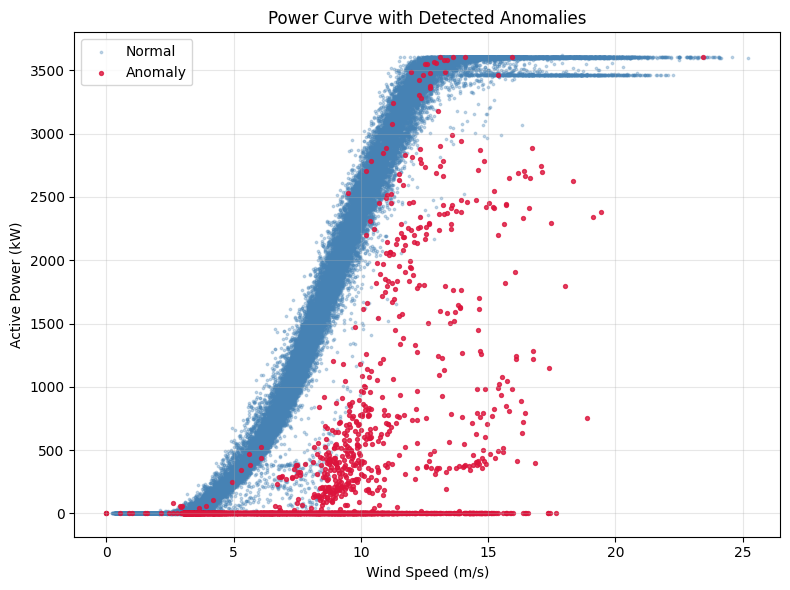

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    normal["Wind Speed (m/s)"],
    normal["LV ActivePower (kW)"],
    s=3,
    alpha=0.3,
    color="steelblue",
    label="Normal"
)

plt.scatter(
    anom["Wind Speed (m/s)"],
    anom["LV ActivePower (kW)"],
    s=8,
    alpha=0.8,
    color="crimson",
    label="Anomaly"
)

plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Active Power (kW)")
plt.title("Power Curve with Detected Anomalies")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 2. Power Over Time

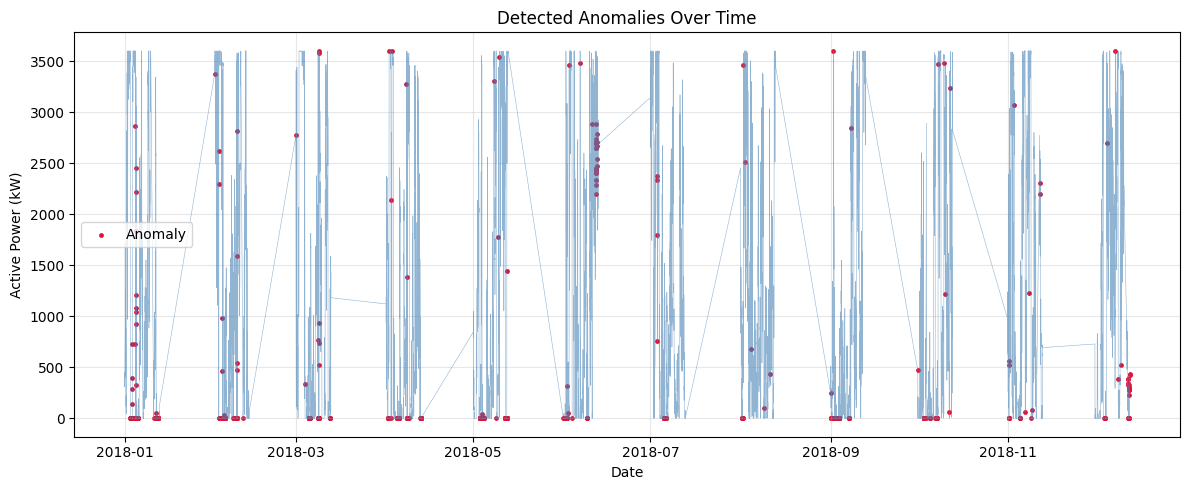

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["Date/Time"],
    df["LV ActivePower (kW)"],
    lw=0.4,
    color="steelblue",
    alpha=0.6
)

plt.scatter(
    anom["Date/Time"],
    anom["LV ActivePower (kW)"],
    s=6,
    color="crimson",
    label="Anomaly"
)

plt.title("Detected Anomalies Over Time")
plt.xlabel("Date")
plt.ylabel("Active Power (kW)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Rule-Based Reasons

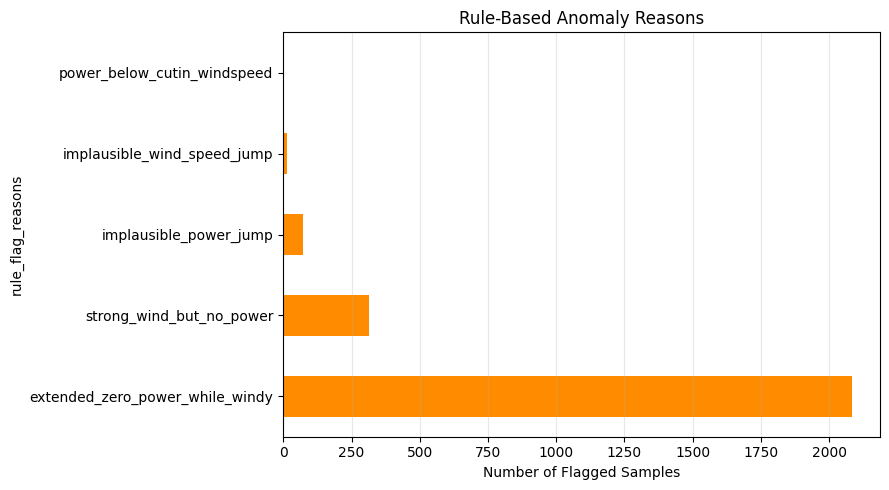

In [ ]:
reason_counts = (
    df["rule_flag_reasons"]
    .str.split(";")
    .explode()
    .replace("", np.nan)
    .dropna()
    .value_counts()
)

plt.figure(figsize=(9, 5))

if len(reason_counts) > 0:
    reason_counts.plot(kind="barh", color="darkorange")

plt.title("Rule-Based Anomaly Reasons")
plt.xlabel("Number of Flagged Samples")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


# 4. Isolation Forest Scores

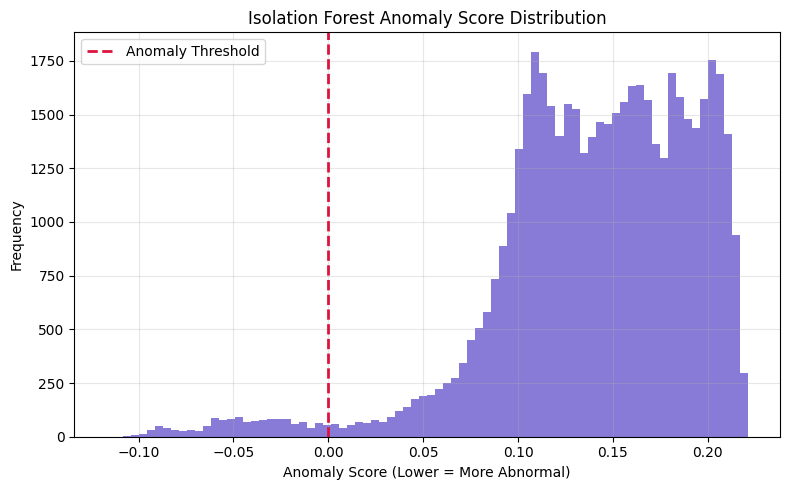

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["model_anomaly_score"],
    bins=80,
    color="slateblue",
    alpha=0.8
)

plt.axvline(
    df.loc[df["model_anomaly"], "model_anomaly_score"].max(),
    color="crimson",
    linestyle="--",
    linewidth=2,
    label="Anomaly Threshold"
)

plt.title("Isolation Forest Anomaly Score Distribution")
plt.xlabel("Anomaly Score (Lower = More Abnormal)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Inspect flagged rows

In [ ]:
flagged = df[df["any_anomaly"]].copy()
flagged[["Date/Time", "LV ActivePower (kW)", "Wind Speed (m/s)",
         "Wind Direction (°)", "rule_flag_reasons", "model_anomaly",
         "model_anomaly_score"]].head(20)

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Wind Direction (°),rule_flag_reasons,model_anomaly,model_anomaly_score
288,2018-01-03 00:00:00,0.0,4.684498,51.169159,extended_zero_power_while_windy;implausible_po...,False,0.170951
289,2018-01-03 00:10:00,0.0,4.377705,37.424400,extended_zero_power_while_windy,False,0.166516
290,2018-01-03 00:20:00,0.0,3.969311,26.126591,extended_zero_power_while_windy,False,0.163556
291,2018-01-03 00:30:00,0.0,4.819459,37.092079,extended_zero_power_while_windy,False,0.150304
292,2018-01-03 00:40:00,0.0,5.434208,32.177010,extended_zero_power_while_windy,False,0.110643
293,2018-01-03 00:50:00,0.0,5.599916,28.515631,extended_zero_power_while_windy,False,0.100366
294,2018-01-03 01:00:00,0.0,5.864426,29.605619,extended_zero_power_while_windy,False,0.092996
295,2018-01-03 01:10:00,0.0,5.481966,28.339920,extended_zero_power_while_windy,False,0.102371
296,2018-01-03 01:20:00,0.0,6.521284,17.447411,extended_zero_power_while_windy,False,0.045155
297,2018-01-03 01:30:00,0.0,6.490254,20.354931,extended_zero_power_while_windy,False,0.053317


## Save outputs

In [ ]:
from pathlib import Path

outdir = Path("out")
outdir.mkdir(exist_ok=True)

flagged.to_csv(outdir / "flagged_anomalies.csv", index=False)
df.to_csv(outdir / "full_data_with_flags.csv", index=False)
with open(outdir / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved:")
print(f"  {outdir/'full_data_with_flags.csv'}  (all rows + flag columns)")
print(f"  {outdir/'flagged_anomalies.csv'}      (only flagged rows)")
print(f"  {outdir/'summary.json'}               (counts by reason)")

Saved:
  out/full_data_with_flags.csv  (all rows + flag columns)
  out/flagged_anomalies.csv      (only flagged rows)
  out/summary.json               (counts by reason)


## Evaluation — synthetic fault injection

There's no ground-truth "this row is a sensor fault" label in this dataset, so
Isolation Forest can't be scored with a normal train/test split. Instead we
**inject known, synthetic sensor faults** into rows that the pipeline
currently considers clean, then re-run the full pipeline and measure:

- **Recall per fault type** — what fraction of injected faults got caught
- **False positive rate** — of the untouched clean rows, how many now get
  flagged (should be low)

This tells us how sensitive the pipeline actually is to each failure mode,
rather than just eyeballing the plots.

In [ ]:
rng = np.random.default_rng(42)

# start from a fresh copy, and only inject into rows the pipeline currently
# considers clean, so we have unambiguous ground truth
clean_pool = df.index[~df["any_anomaly"]].to_numpy()

N_PER_TYPE = 40
MIN_GAP = 15  # rows between injected windows so they don't overlap

def pick_indices(pool, n, min_gap, rng):
    pool = np.sort(rng.permutation(pool))
    chosen = []
    last = -min_gap
    for idx in pool:
        if idx - last >= min_gap and idx > STUCK_RUN_LENGTH and idx < len(df) - STUCK_RUN_LENGTH:
            chosen.append(idx)
            last = idx
        if len(chosen) == n:
            break
    return chosen

eval_df = df.copy()
injected = {}  # fault_type -> set of row indices

# 1. Stuck power sensor: freeze power for STUCK_RUN_LENGTH+2 consecutive rows
idx_list = pick_indices(clean_pool, N_PER_TYPE, MIN_GAP, rng)
rows = []
for start in idx_list:
    freeze_val = eval_df.loc[start, "LV ActivePower (kW)"]
    span = range(start, start + STUCK_RUN_LENGTH + 2)
    eval_df.loc[span, "LV ActivePower (kW)"] = freeze_val
    rows.extend(span)
injected["stuck_power_sensor"] = set(rows)

# 2. Stuck wind speed sensor
idx_list = pick_indices(clean_pool, N_PER_TYPE, MIN_GAP, rng)
rows = []
for start in idx_list:
    freeze_val = eval_df.loc[start, "Wind Speed (m/s)"]
    span = range(start, start + STUCK_RUN_LENGTH + 2)
    eval_df.loc[span, "Wind Speed (m/s)"] = freeze_val
    rows.extend(span)
injected["stuck_wind_speed_sensor"] = set(rows)

# 3. Out-of-range wind direction (single-point glitch, e.g. logger overflow)
idx_list = pick_indices(clean_pool, N_PER_TYPE, MIN_GAP, rng)
for i in idx_list:
    eval_df.loc[i, "Wind Direction (°)"] = rng.choice([-15, 380, 420])
injected["out_of_range_direction"] = set(idx_list)

# 4. Implausible single-step power jump/spike
idx_list = pick_indices(clean_pool, N_PER_TYPE, MIN_GAP, rng)
for i in idx_list:
    jump = rng.choice([-1, 1]) * rng.uniform(MAX_POWER_JUMP * 1.3, MAX_POWER_JUMP * 2)
    new_val = np.clip(eval_df.loc[i, "LV ActivePower (kW)"] + jump, -100, RATED_POWER_KW * 1.05)
    eval_df.loc[i, "LV ActivePower (kW)"] = new_val
injected["implausible_power_jump"] = set(idx_list)

# 5. Spurious isolated zero-power reading during strong wind (single point,
#    distinguishable from real curtailment which tends to run longer)
idx_list = pick_indices(clean_pool, N_PER_TYPE, MIN_GAP, rng)
for i in idx_list:
    eval_df.loc[i, "Wind Speed (m/s)"] = rng.uniform(STRONG_WIND_SPEED + 1, STRONG_WIND_SPEED + 4)
    eval_df.loc[i, "LV ActivePower (kW)"] = 0
injected["spurious_zero_power_strong_wind"] = set(idx_list)

# recompute columns that depend on the raw sensors we just corrupted
eval_df["power_deviation"] = eval_df["LV ActivePower (kW)"] - eval_df["Theoretical_Power_Curve (KWh)"]
eval_df["wind_direction_sin"] = np.sin(np.radians(eval_df["Wind Direction (°)"]))
eval_df["wind_direction_cos"] = np.cos(np.radians(eval_df["Wind Direction (°)"]))

all_injected = set().union(*injected.values())
print(f"Injected {len(all_injected):,} synthetic-fault rows across {len(injected)} fault types")

Injected 320 synthetic-fault rows across 5 fault types


In [ ]:
# re-run the full pipeline on the corrupted data
eval_rule_reasons = (
    flag_out_of_range(eval_df)
    + flag_stuck_sensor(eval_df)
    + flag_power_curve_inconsistency(eval_df)
    + flag_implausible_jumps(eval_df)
)
eval_df["rule_flag_reasons"] = eval_rule_reasons.str.rstrip(";")
eval_df["rule_based_anomaly"] = eval_df["rule_flag_reasons"].str.len() > 0

eval_features = eval_df[
    ["Wind Speed (m/s)", "power_deviation", "wind_direction_sin", "wind_direction_cos"]
]
# reuse the SAME scaler fitted on the original clean data (not re-fit),
# mirroring how a scaler fit on training data gets reused on new data in production
eval_features_scaled = scaler.transform(eval_features)

# Fit the eval Isolation Forest only on rows Layer 1 still considers clean
# *after* corruption. Injected faults that already trip a rule are excluded
# automatically; this also keeps the eval model honest with the production
# pipeline above — it never trains on the very anomalies we're about to
# measure recall against.
eval_train_mask = ~eval_df["rule_based_anomaly"]

eval_model = IsolationForest(
    n_estimators=300, contamination=IFOREST_CONTAMINATION, random_state=42, n_jobs=-1
)
eval_model.fit(eval_features_scaled[eval_train_mask.to_numpy()])
eval_pred = eval_model.predict(eval_features_scaled)

eval_df["model_anomaly"] = eval_pred == -1
eval_df["any_anomaly"] = eval_df["rule_based_anomaly"] | eval_df["model_anomaly"]

flagged_idx = set(eval_df.index[eval_df["any_anomaly"]])
rule_flagged_idx = set(eval_df.index[eval_df["rule_based_anomaly"]])
model_flagged_idx = set(eval_df.index[eval_df["model_anomaly"]])


In [ ]:
# Recall per fault type
results = []
for fault_type, rows in injected.items():
    caught_any = rows & flagged_idx
    caught_rule = rows & rule_flagged_idx
    caught_model = rows & model_flagged_idx
    results.append({
        "fault_type": fault_type,
        "n_injected_rows": len(rows),
        "recall_combined": round(len(caught_any) / len(rows), 3),
        "recall_rule_based": round(len(caught_rule) / len(rows), 3),
        "recall_model_only": round(len(caught_model) / len(rows), 3),
    })
recall_table = pd.DataFrame(results)
print(recall_table.to_string(index=False))

# False positive rate: clean rows (never injected) that got flagged anyway
untouched_clean = np.array(list(set(clean_pool) - all_injected))
fp = len(set(untouched_clean) & flagged_idx)
fp_rate = fp / len(untouched_clean)
print(f"\nFalse positive rate on untouched clean rows: {fp_rate:.4%}  ({fp:,} / {len(untouched_clean):,})")

                     fault_type  n_injected_rows  recall_combined  recall_rule_based  recall_model_only
             stuck_power_sensor              320            0.963              0.959              0.103
        stuck_wind_speed_sensor              320            0.963              0.959              0.103
         out_of_range_direction               40            1.000              1.000              0.625
         implausible_power_jump               40            1.000              1.000              0.625
spurious_zero_power_strong_wind               40            1.000              1.000              0.625

False positive rate on untouched clean rows: 0.0653%  (31 / 47,465)


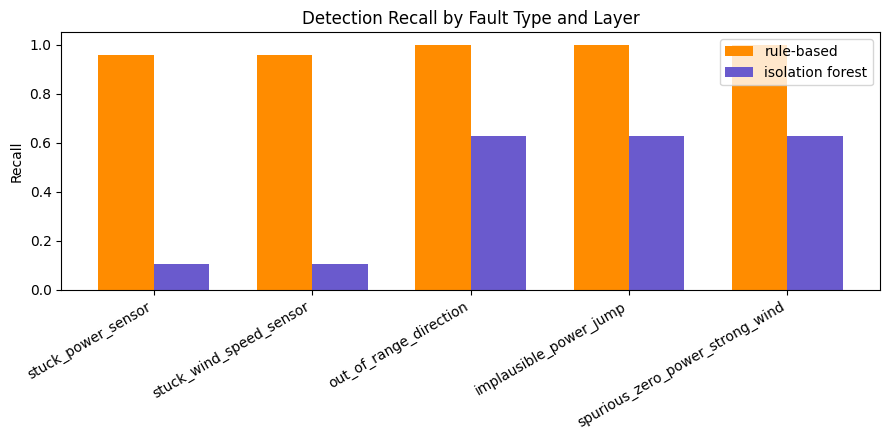

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(recall_table))
width = 0.35
ax.bar(x - width/2, recall_table["recall_rule_based"], width, label="rule-based", color="darkorange")
ax.bar(x + width/2, recall_table["recall_model_only"], width, label="isolation forest", color="slateblue")
ax.set_xticks(x)
ax.set_xticklabels(recall_table["fault_type"], rotation=30, ha="right")
ax.set_ylabel("Recall")
ax.set_ylim(0, 1.05)
ax.set_title("Detection Recall by Fault Type and Layer")
ax.legend()
plt.tight_layout()
plt.show()

**How to read this:** the rule-based layer should catch the fault types it
was explicitly designed for (stuck sensors, out-of-range values, jumps) at
close to 100% recall, since those are deterministic checks. The Isolation
Forest bars show how much *extra* coverage the model layer adds on top —
useful for fault types that don't cleanly match a hand-written rule, or as a
safety net if a rule's threshold is slightly off. A low false-positive rate
confirms the pipeline isn't just flagging everything.

In [ ]:
df.to_csv(outdir / "eval_data_with_flags.csv", index=False)

In [ ]:
import joblib
from pathlib import Path

model_dir = Path("models")
model_dir.mkdir(exist_ok=True)

joblib.dump(model, model_dir / "isolation_forest.pkl")
joblib.dump(scaler, model_dir / "standard_scaler.pkl")


['models/standard_scaler.pkl']